In [1]:
import warnings
warnings.filterwarnings('ignore')

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1200px-Pandas_logo.svg.png" width="25%" height="25%" />

# Pandas - Topic 13 - Long x Wide format

* Differentiate a dataset in a long or wide format

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Packages for Learning

In [2]:
import numpy as np
import pandas as pd

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Long x Wide format

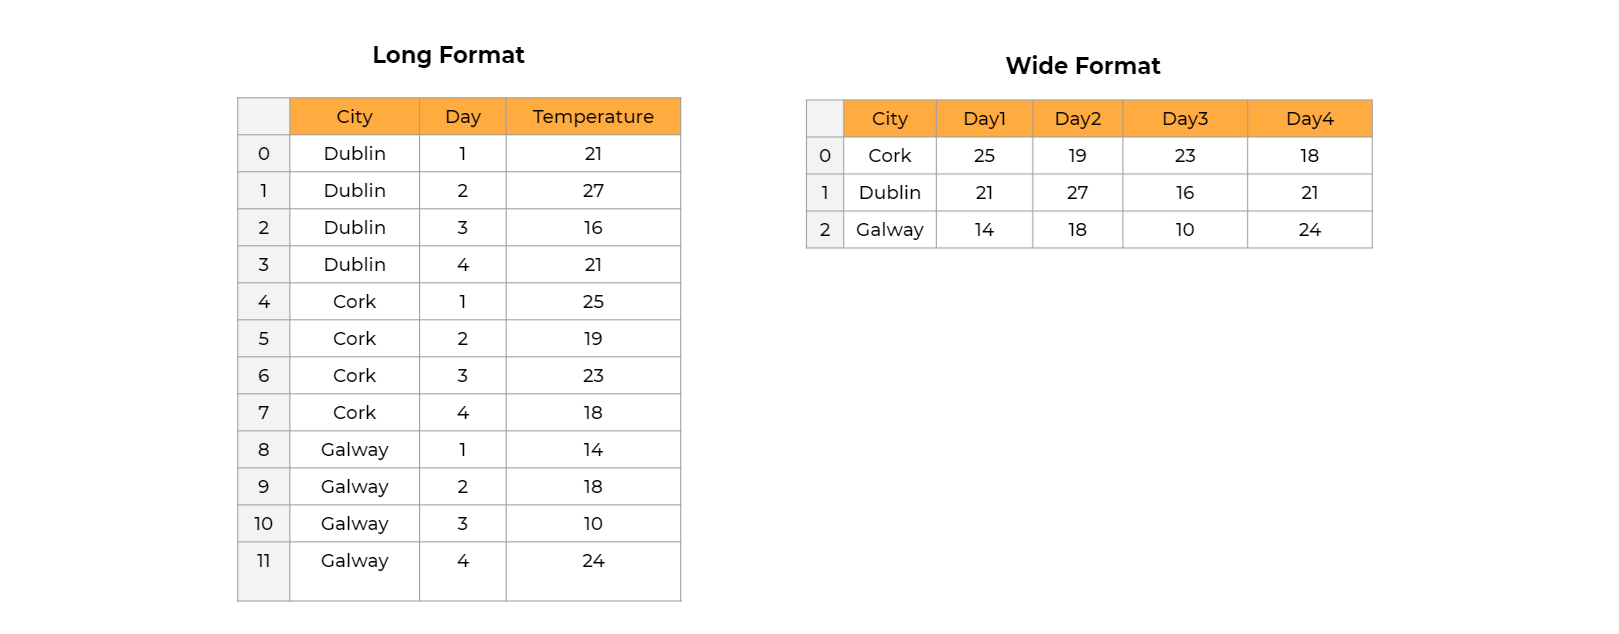

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Your data can be in the **long** or the **wide** format

* In a **long** format, every row represents an observation belonging to a particular category.
* In a **wide** format, categorical data is grouped. You can frame it as a summary of long data. It is typically easier to read and interpret compared to the long format. 



<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

The **need** to consider long or wide formats is because a given function (imported from the libraries used in data science) may be constructed considering one format or another. It will be your job to pre-process the data to properly combine your data and the functions imported from the libraries




Let's see the examples below so we can understand the use cases

* Consider the following dataset: invented **records for Average Temperature for four days in 3 different cities**.
  * You can create using the techniques you have learned so far. The example below is in the **long format**, where the dataset has a column for possible variable types (City, Day, Temperature).
  * Each cell value is a representation of the column it is related to.
    * For example, when you see 1 under the 'Day' column, you know you are referring to: day. 
    * When you see 21 under the 'Temperature' column, you know it is a temperature
  * The more data you add (imagine if you keep adding days for a giving city), the more the DataFrame will grow vertically, in a "long" way


In [3]:
import numpy as np
np.random.seed(seed=101)

df_long = pd.DataFrame(data= {'City':['Dublin','Dublin','Dublin','Dublin',
                                      'Cork','Cork','Cork','Cork','Galway',
                                      'Galway','Galway','Galway'],
                              'Day':[1,2,3,4]*3,
                              'AvgTemperature': np.random.randint(10,30,12)})

df_long

,City,Day,AvgTemperature
0,Dublin,1,21
1,Dublin,2,27
2,Dublin,3,16
3,Dublin,4,21
4,Cork,1,25
5,Cork,2,19
6,Cork,3,23
7,Cork,4,18
8,Galway,1,14
9,Galway,2,18


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

The same dataset could be represented in a different format
  * The example below is in the **wide format**. 
  * Each cell value is the response for the set of variables. In this case, it is a temperature value, for a given day, in a given city
    * When you see 25 under the 'Day1' column, you know it is a temperature.

  * The more data you add (imagine if you keep adding days for a given city), the more the DataFrame will grow horizontally, in a "wide" way.

In [4]:
df_wide = pd.DataFrame(data= {'City': ['Cork','Dublin','Galway'],
                              'Day1':[25,21,14],
                              'Day2':[19,27,18],
                              'Day3':[23,16,10],
                              'Day4':[18,21,24]}
                  )
df_wide

,City,Day1,Day2,Day3,Day4
0,Cork,25,19,23,18
1,Dublin,21,27,16,21
2,Galway,14,18,10,24


Naturally, you will not hard-code the transformation from one format to another. 
  * To transform Long to Wide, use **pd.pivot_table()**  . The documentation is found [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html). 
  * To transform Wide to Long, use **pd.melt()**. The documentation is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html)

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Pivot Table

Let's learn the use cases
  * Consider your long DataFrame

In [5]:
df_long

,City,Day,AvgTemperature
0,Dublin,1,21
1,Dublin,2,27
2,Dublin,3,16
3,Dublin,4,21
4,Cork,1,25
5,Cork,2,19
6,Cork,3,23
7,Cork,4,18
8,Galway,1,14
9,Galway,2,18


You can transform it to a wide format using `pd.pivot_table(`)
  * index are the variables you want to remain untouched. In this case, it is one variable: '`City`'
  * columns are the variables you want to spread. In this case, it is: '`Day`'
  * values are the numerical values you want to aggregate/process

In [6]:
pd.pivot_table(data=df_long,
               index=['City'],
               columns=['Day'],
               values='AvgTemperature')

Day,1,2,3,4
City,,,,
Cork,25.0,19.0,23.0,18.0
Dublin,21.0,27.0,16.0,21.0
Galway,14.0,18.0,10.0,24.0


You will notice that the output is a DataFrame with multi-index: `Day` and `City.` You can transform it to a more conventional format by applying the methods `reset_index()` and `rename_axis(),` using additional processing to format the DataFrame nicely.
  * `.rename_axis()` is used to set the name of the axis for the index.
  * `mapper` sets the name, in this case `None`
  * `axis=1` indicates you want to rename the index

The documentation is [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename_axis.html)

In [7]:
pd.pivot_table(data=df_long,
               index='City',
               columns='Day',
               values='AvgTemperature').reset_index().rename_axis(mapper=None, axis=1)

,City,1,2,3,4
0,Cork,25.0,19.0,23.0,18.0
1,Dublin,21.0,27.0,16.0,21.0
2,Galway,14.0,18.0,10.0,24.0


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

 **PRACTICE**: We will consider historical sales data for 45 stores located in different regions - each store contains a number of departments. Let’s load the DataFrame, set the type of ‘Date’ column as ‘datetime64’’, select rows for the 1st department only and drop columns "Dept","IsHoliday”. The code for such actions is shown below.

In [8]:
df_long_practice = pd.read_csv("sales_data-set.csv")
df_long_practice =df_long_practice.astype({'Date':"datetime64[ns]"})
df_long_practice=df_long_practice[df_long_practice['Dept']==1]
df_long_practice=df_long_practice.drop(["Dept","IsHoliday"], axis=1)
df_long_practice

,Store,Date,Weekly_Sales
0,1,2010-05-02,24924.50
1,1,2010-05-03,21827.90
2,1,2010-05-14,18926.74
3,1,2010-05-21,14773.04
4,1,2010-05-28,15580.43
...,...,...,...
20009,45,2010-05-14,12908.53
20010,45,2010-05-21,12319.70
20011,45,2010-05-28,12037.59
20012,45,2010-06-08,11089.67


Using the pivot_table function
* set index to `Store`, set columns to `Date` and set values to `Weekly_Sales`
* Then reset the index 
* Then use rename_axis, setting mapper to None and axis to 1 
* Assign you result to `df_wide_practice`

In [9]:
# Write your code here.
df_wide_practice = pd.pivot_table(data=df_long_practice,
                                  index='Store',
                                  columns='Date',
                                  values='Weekly_Sales').reset_index().rename_axis(mapper=None, axis=1)
df_wide_practice

,Store,2010-05-02 00:00:00,2010-05-03 00:00:00,2010-05-11 00:00:00,2010-05-14 00:00:00,2010-05-21 00:00:00,2010-05-28 00:00:00,2010-06-08 00:00:00
0,1,24924.50,21827.90,34238.88,18926.74,14773.04,15580.43,17508.41
1,2,35034.06,27372.05,46198.84,25876.55,22689.01,22899.73,22795.72
2,3,6453.58,5172.73,14326.87,4771.24,4444.92,4204.65,3552.70
3,4,38724.42,31580.69,48727.62,27649.17,27138.28,25405.65,24769.54
4,5,9323.89,8344.13,11137.94,7575.66,7566.13,7869.37,7148.15
5,6,25619.00,22839.36,34633.25,20531.13,17862.63,19758.10,21055.66
6,7,8970.97,9541.12,12744.21,6612.82,6972.83,6321.96,8147.74
7,8,16181.89,12979.74,24364.54,11729.98,10456.40,10495.15,10360.57
8,9,12861.40,10438.47,18538.13,9527.04,8969.28,8674.07,8888.16
9,10,40212.84,36572.44,68006.65,30021.02,30251.76,29958.02,26778.10


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

###  Melt

You can transform from wide to long. Let's recap df_wide

In [10]:
df_wide

,City,Day1,Day2,Day3,Day4
0,Cork,25,19,23,18
1,Dublin,21,27,16,21
2,Galway,14,18,10,24


Use` pd.melt()`
  * `frame` is the DataFrame
  * `var_name` is the categorical column name you will create
  * `value_name` is the numerical column name you will create
  * `value_vars` are the columns you will "shrink" or "melt"
  * `id_vars` are columns to use as identifier variables or variables that will remain untouched.

In [11]:
pd.melt(frame=df_wide,
        var_name='Day',
        value_name='AverageTemperature',
        value_vars=['Day1','Day2','Day3','Day4'],
        id_vars=['City'])

,City,Day,AverageTemperature
0,Cork,Day1,25
1,Dublin,Day1,21
2,Galway,Day1,14
3,Cork,Day2,19
4,Dublin,Day2,27
5,Galway,Day2,18
6,Cork,Day3,23
7,Dublin,Day3,16
8,Galway,Day3,10
9,Cork,Day4,18


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

 **PRACTICE**: We will consider the first 4 weeks of our Store sales data combined in a wide format previously. For easy usage we will rename the first 4 weekly columns to 'Week1','Week2','Week3','Week4' respectively. The code for such actions is shown below.


In [12]:
df_wide_practice = df_wide.iloc[0:,0:5]
df_wide_practice.columns=['Store','Week1','Week2','Week3','Week4']
df_wide_practice

,Store,Week1,Week2,Week3,Week4
0,Cork,25,19,23,18
1,Dublin,21,27,16,21
2,Galway,14,18,10,24


Using **melt** set the frame to `df_wide_practice`
* Use var_name to create a column named `Week`
* Use value_name to create a column named `WeeklySales`
* Use value_vars to melt the columns from Week 1 through to Week 4
* Use id_vars on the `Store` column, as this should remain untouched.

In [13]:
# Write your code here.
pd.melt(frame=df_wide_practice,
        var_name='Week',
        value_name='Weekly_Sales',
        value_vars=['Week1','Week2','Week3','Week4'],
        id_vars=['Store'])

,Store,Week,Weekly_Sales
0,Cork,Week1,25
1,Dublin,Week1,21
2,Galway,Week1,14
3,Cork,Week2,19
4,Dublin,Week2,27
5,Galway,Week2,18
6,Cork,Week3,23
7,Dublin,Week3,16
8,Galway,Week3,10
9,Cork,Week4,18


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Pivot Table to generate statistics

Another use case for **pd.pivot_table()** is to generate a table of statistics that helps summarise the data of a larger table


Consider the following dataset. 
  * It shows records for diamond prices and their characteristics, like colour, cut, clarity and depth

In [14]:
import seaborn as sns
df = sns.load_dataset('diamonds')
df = df.head(200)
print(df.shape)
df.head(10)

(200, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


You are interested in summarising and checking the mean price per cut and colour.
* Note we have multiple rows of the same cut and colour The example below queries data where: cut == 'Ideal' and colour == 'E'.

  * Therefore we need to use an aggregation function when using a pivot table. In this case, we will use: 'mean'

In [15]:
df.query("cut == 'Ideal' and color == 'E'")

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
82,0.26,Ideal,E,VVS2,62.9,58.0,554,4.02,4.06,2.54
90,0.70,Ideal,E,SI1,62.5,57.0,2757,5.70,5.72,3.57
109,0.59,Ideal,E,VVS2,62.0,55.0,2761,5.38,5.43,3.35
111,0.74,Ideal,E,SI2,62.2,56.0,2761,5.80,5.84,3.62
118,0.70,Ideal,E,VS2,60.7,58.0,2762,5.73,5.76,3.49
121,0.74,Ideal,E,SI1,62.3,54.0,2762,5.80,5.83,3.62
149,0.70,Ideal,E,SI1,60.9,57.0,2768,5.73,5.76,3.50
173,0.60,Ideal,E,VS1,61.7,55.0,2774,5.41,5.44,3.35
174,0.70,Ideal,E,SI1,62.7,55.0,2774,5.68,5.74,3.58


These are the arguments for `pd.pivot_table()`
  * `values` are 'price' and `aggfunc` is 'mean'
  * `index` is 'cut and `columns` are 'colour'



In the end, you can check the price level for each cut and colour

In [16]:
pd.pivot_table(data=df,
               index='cut',
               columns='color',
               values='price',
               aggfunc='mean')

color,D,E,F,G,H,I,J
cut,,,,,,,
Ideal,2213.750000,2458.733333,2765.125000,2386.083333,2764.000000,1082.909091,362.333333
Premium,1853.400000,1924.000000,2084.000000,2323.900000,1184.714286,911.200000,405.000000
Very Good,1624.571429,1150.600000,1867.538462,1995.333333,1188.555556,382.000000,754.000000
Good,403.000000,1362.800000,2178.750000,2776.000000,905.800000,1176.666667,344.000000
Fair,NaN,1547.000000,2761.000000,NaN,2763.000000,NaN,NaN


Imagine now that you are interested in summarising and checking the max price per cut and colour per clarity.
  * Your index will be a list: ['cut','color']. 
  * Your columns will be: 'clarity'
  * You will notice few cells have NaN, indicating that particular combination doesn't exist
   * You can use the parameter ``fill_value`` and set it to a suitable value to replace missing values with; a good value, in this case, would be 0
  * You will also notice that this transformation, as it is, is not super insightful since we create a chunk of numbers. However, this processing step prepares the data to be parsed to a function where you could potentially visualise the data and extract useful insights. We will do that in future lessons

In [17]:
pd.pivot_table(data=df,
               index=['cut','color'],
               columns='clarity',
               values='price',
               fill_value=0,
               aggfunc='max')

clarity            VVS1    VVS2     VS1     VS2     SI1     SI2      I1
cut       color                                                        
Ideal     D         0.0     0.0     0.0     0.0  2764.0  2773.0     0.0
          E         0.0  2776.0  2774.0  2777.0  2777.0  2761.0     0.0
          F      2772.0     0.0     0.0  2762.0  2770.0  2771.0     0.0
          G      2772.0   553.0   404.0  2771.0  2776.0     0.0     0.0
          H         0.0     0.0     0.0  2763.0  2765.0     0.0     0.0
          I       553.0  2761.0  2760.0     0.0  2769.0   554.0     0.0
          J         0.0     0.0   340.0     0.0   403.0   344.0     0.0
Premium   D         0.0     0.0     0.0  2773.0   552.0  2768.0     0.0
          E      2765.0     0.0     0.0  2777.0  2777.0   345.0   345.0
          F         0.0     0.0  2765.0  2777.0  2777.0  2762.0     0.0
          G       554.0     0.0  2770.0  2770.0  2760.0     0.0     0.0
          H       554.0   554.0     0.0     0.0  2763.0     0.0     0.0
          I         0.0     0.0   355.0  2761.0   554.0   552.0     0.0
          J         0.0     0.0     0.0     0.0     0.0   405.0     0.0
Very Good D       554.0  2763.0  2777.0  2767.0  2768.0     0.0     0.0
          E       554.0   554.0   402.0  2765.0  2760.0     0.0     0.0
          F         0.0   554.0  2767.0  2777.0  2771.0  2772.0     0.0
          G         0.0   354.0  2768.0  2776.0  2762.0  2759.0     0.0
          H      2772.0  2771.0  2765.0     0.0   554.0   404.0     0.0
          I       336.0     0.0     0.0     0.0   405.0     0.0     0.0
          J         0.0   336.0     0.0   357.0   353.0     0.0  2774.0
Good      D         0.0     0.0   403.0   403.0     0.0     0.0     0.0
          E       554.0     0.0   402.0  2772.0     0.0     0.0     0.0
          F         0.0     0.0  2759.0  2777.0     0.0     0.0     0.0
          G         0.0     0.0     0.0  2776.0     0.0     0.0     0.0
          H         0.0  2767.0     0.0     0.0   554.0   403.0     0.0
          I         0.0     0.0     0.0  2774.0   405.0   351.0     0.0
          J         0.0     0.0     0.0     0.0   351.0   335.0     0.0
Fair      E         0.0     0.0     0.0   337.0     0.0  2757.0     0.0
          F         0.0     0.0     0.0  2762.0     0.0  2759.0     0.0
          H         0.0     0.0     0.0     0.0     0.0  2763.0     0.0

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

 **PRACTICE**: We will consider the tips dataset for practice. It holds records for waiter tips, based on the day of the week, time of the day, total bill, gender, if it is a table of smokers or not, and how many people were at the table.

In [18]:
df_practice = sns.load_dataset('tips')
print(f"DataFrame shape: {df_practice.shape}")
df_practice.head(50)

DataFrame shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


You have to choose your days and times to work; you want to check which days you should work and which shift to maximise your potential tips.

To retrieve this data, you need to use a pivot_table and set data to df_practice
* You will need to set index as ``day`` and ``time``.
* To see which tables give the most tips, you will need to set columns to ``size``
* And as you are interested in tips, you will need to set values to ``tip``
* For the aggfunc you will use ``sum``
* And so as not to have NaN showing set ``fill_value`` to 0

When you run this, you should have a good idea of what days and shifts to work.

In [19]:
# Write your code here.
pd.pivot_table(data=df_practice,
               index=['day', 'time'],
               columns='size',
               values='tip',
               aggfunc='sum',
               fill_value=0)

size            1       2      3      4      5     6
day  time                                           
Thur Lunch   1.83  114.24  10.77  21.09   5.00  15.9
     Dinner  0.00    3.00   0.00   0.00   0.00   0.0
Fri  Lunch   1.92   11.76   3.00   0.00   0.00   0.0
     Dinner  0.00   30.55   0.00   4.73   0.00   0.0
Sat  Lunch   0.00    0.00   0.00   0.00   0.00   0.0
     Dinner  2.00  133.43  68.36  53.61   3.00   0.0
Sun  Lunch   0.00    0.00   0.00   0.00   0.00   0.0
     Dinner  0.00  109.86  46.81  73.58  12.14   5.0

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> 

**WARNING** 

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png">


You might have noticed up to this point; there is a lot covered in Pandas, multiple functions/methods with multiple use cases.
  * It is virtually **IMPOSSIBLE** to remember all functions and all arguments. Using library documentation is fundamental to developing a project.
  * Naturally, over time you will get familiar with and used to the most common use cases, but in general, a data professional spends **a lot of time** searching the Internet for the documentation and uses cases.